# Guitar Chord Recognition — CNN Model

**University project — Machine Learning**

Pipeline: `audio -> mel-spectrogram -> CNN -> chord`

Dataset: [Guitar Chords V3](https://www.kaggle.com/datasets/fabianavinci/guitar-chords-v3)

---

### How to run
1. **Runtime -> Change runtime type -> T4 GPU** (free)
2. Run cells in order (Shift+Enter)
3. For cell 5 you'll need Kaggle credentials (see instructions there)


## 1. Install packages

In [1]:
!pip install -q librosa scikit-learn seaborn kagglehub

## 2. Imports and GPU check

In [2]:
import os
import random
import numpy as np
import librosa
import librosa.display
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: no GPU available, training will be slow. Go to Runtime -> Change runtime type -> T4 GPU')

Using: cuda
GPU: NVIDIA GeForce RTX 3070 Laptop GPU


## 3. Download dataset from Kaggle (kagglehub)

**Authentication — pick one of two options:**

**A) Easiest: Colab Secrets** (recommended)
1. Click the key icon on the left (`Secrets`)
2. Add two secrets:
   - `KAGGLE_USERNAME` -> your Kaggle username
   - `KAGGLE_KEY` -> API key (Kaggle -> Settings -> Create New API Token, open `kaggle.json` and copy `key`)
3. Enable "Notebook access" for both

**B) Upload kaggle.json** — uncomment the alternative block below

In [3]:
import os

# Detect environment: Colab vs local
try:
    from google.colab import userdata  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # --- Option A: Colab Secrets ---
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')

    # --- Option B: upload kaggle.json (uncomment if not using Secrets) ---
    # from google.colab import files
    # files.upload()  # select kaggle.json
    # !mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
else:
    # --- Local run ---
    # kagglehub accepts any one of:
    #   1) env vars KAGGLE_USERNAME + KAGGLE_KEY
    #   2) ~/.kaggle/kaggle.json   (legacy API token)
    #   3) ~/.kaggle/access_token  (new KGAT_... token from Kaggle Settings)
    kaggle_dir   = os.path.expanduser('~/.kaggle')
    kaggle_json  = os.path.join(kaggle_dir, 'kaggle.json')
    access_token = os.path.join(kaggle_dir, 'access_token')
    if not (os.environ.get('KAGGLE_KEY')
            or os.path.exists(kaggle_json)
            or os.path.exists(access_token)):
        raise RuntimeError(
            'No Kaggle credentials found. Either:\n'
            '  a) export KAGGLE_USERNAME=... KAGGLE_KEY=...\n'
            f'  b) place kaggle.json at {kaggle_json} (chmod 600)\n'
            f'  c) place KGAT_... access token at {access_token} (chmod 600)'
        )

import kagglehub
DATASET_PATH = kagglehub.dataset_download('fabianavinci/guitar-chords-v3')
print(f'Dataset downloaded to: {DATASET_PATH}')
!ls "$DATASET_PATH"


/home/lazic/Documents/projects/chord-recognition/backend/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: /home/lazic/.cache/kagglehub/datasets/fabianavinci/guitar-chords-v3/versions/1
Test  Training


## 4. Explore the dataset

In [4]:
DATA_DIR = Path(DATASET_PATH)

# Find all folders that contain .wav files (structure: .../<class>/<file>.wav)
def find_class_folders(root):
    folders = {}
    for path in root.rglob('*.wav'):
        cls = path.parent.name
        folders.setdefault(cls, []).append(path)
    return folders

class_files = find_class_folders(DATA_DIR)
print(f'Number of classes: {len(class_files)}')
for cls, paths in sorted(class_files.items()):
    print(f'  {cls}: {len(paths)} files')

CLASSES = sorted(class_files.keys())
NUM_CLASSES = len(CLASSES)
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
print(f'\nClasses: {CLASSES}')

Number of classes: 8
  Am: 220 files
  Bb: 220 files
  Bdim: 220 files
  C: 220 files
  Dm: 220 files
  Em: 220 files
  F: 220 files
  G: 220 files

Classes: ['Am', 'Bb', 'Bdim', 'C', 'Dm', 'Em', 'F', 'G']


## 5. Preprocessing — audio to mel-spectrogram

**What happens:**
- Load the audio and resample to 22050 Hz
- Take the first 2 seconds (or pad if shorter)
- Compute a **mel-spectrogram** — a frequency representation tuned to human hearing
- Convert to dB scale and normalize to [0, 1]

The result is a 2D matrix that the CNN treats as an "image".

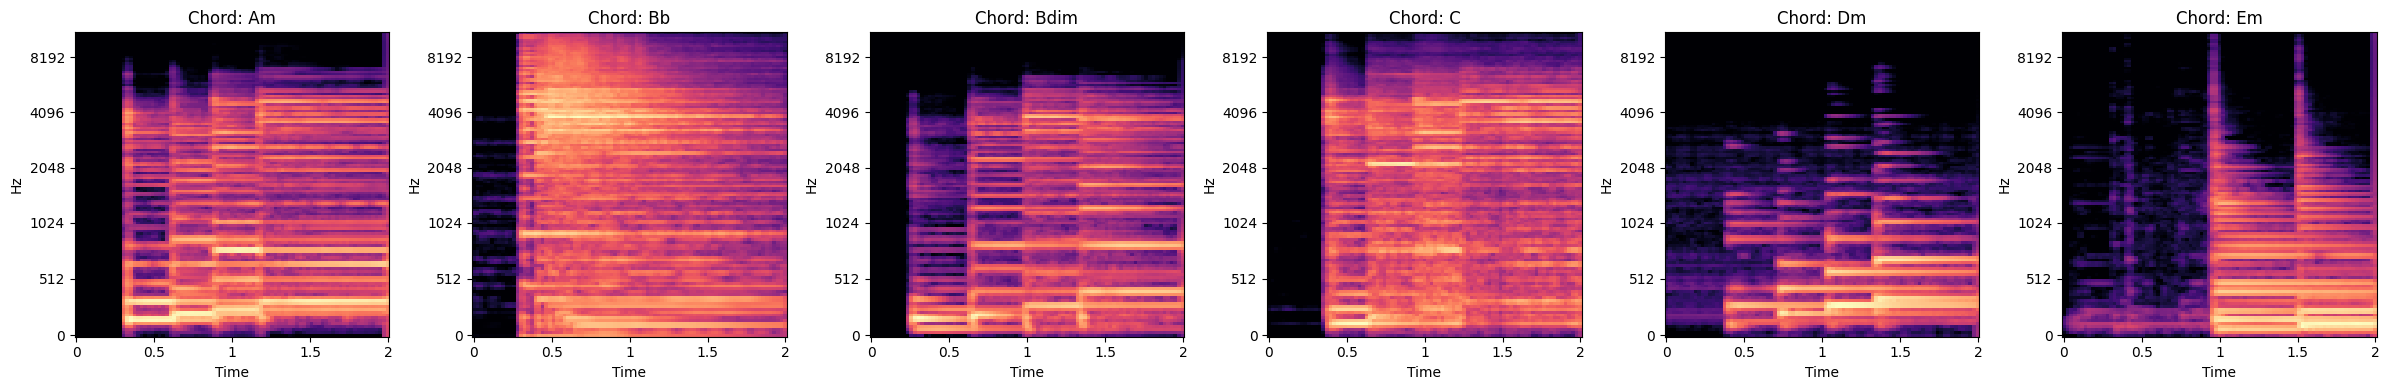

Spectrogram shape: (128, 87)  (n_mels x time_frames)


In [5]:
SAMPLE_RATE = 22050
DURATION = 2.0
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

def audio_to_melspec(file_path):
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
    target_length = int(SAMPLE_RATE * DURATION)
    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)))
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    return mel_db.astype(np.float32)

# Visualize one sample from each class
n_show = min(NUM_CLASSES, 6)
fig, axes = plt.subplots(1, n_show, figsize=(4*n_show, 4))
if n_show == 1:
    axes = [axes]
for ax, cls in zip(axes, CLASSES[:n_show]):
    sample = class_files[cls][0]
    mel = audio_to_melspec(sample)
    librosa.display.specshow(mel, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                              x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(f'Chord: {cls}')
plt.tight_layout()
plt.show()

print(f'Spectrogram shape: {mel.shape}  (n_mels x time_frames)')

## 6. PyTorch Dataset and DataLoader

In [6]:
class ChordDataset(Dataset):
    def __init__(self, file_list, labels):
        self.file_list = file_list
        self.labels = labels

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        mel = audio_to_melspec(self.file_list[idx])
        mel = torch.tensor(mel).unsqueeze(0)  # (1, n_mels, time)
        return mel, self.labels[idx]

# Build the full file/label lists
all_files = []
all_labels = []
for cls, paths in class_files.items():
    for p in paths:
        all_files.append(p)
        all_labels.append(class_to_idx[cls])

dataset = ChordDataset(all_files, all_labels)

# 80/20 train/val split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)
print(f'Train: {len(train_ds)} | Validation: {len(val_ds)}')

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Train: 1408 | Validation: 352


## 7. CNN architecture

3 convolutional blocks (Conv -> BN -> ReLU -> MaxPool) + 2 fully-connected layers with dropout.

In [7]:
class ChordCNN(nn.Module):
    def __init__(self, num_classes, input_shape):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, *input_shape)
            flat_size = self.features(dummy).flatten(1).shape[1]
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

sample_mel = audio_to_melspec(all_files[0])
input_shape = sample_mel.shape
model = ChordCNN(NUM_CLASSES, input_shape).to(device)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

ChordCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=20480, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropou

## 8. Training

In [8]:
EPOCHS = 20
LR = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total

best_val_acc = 0.0
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    marker = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        marker = '  <- new best'

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'train loss {tr_loss:.4f} acc {tr_acc:.3f} | '
          f'val loss {val_loss:.4f} acc {val_acc:.3f}{marker}')

print(f'\nBest validation accuracy: {best_val_acc:.3f}')

Epoch 01/20 | train loss 3.3113 acc 0.185 | val loss 2.0326 acc 0.185  <- new best
Epoch 02/20 | train loss 1.7381 acc 0.322 | val loss 1.2949 acc 0.625  <- new best
Epoch 03/20 | train loss 1.2219 acc 0.526 | val loss 0.6211 acc 0.884  <- new best
Epoch 04/20 | train loss 0.8758 acc 0.643 | val loss 0.3126 acc 0.940  <- new best
Epoch 05/20 | train loss 0.6342 acc 0.719 | val loss 0.2213 acc 0.949  <- new best
Epoch 06/20 | train loss 0.5038 acc 0.786 | val loss 0.2192 acc 0.943
Epoch 07/20 | train loss 0.4691 acc 0.793 | val loss 0.1131 acc 0.966  <- new best
Epoch 08/20 | train loss 0.4477 acc 0.807 | val loss 0.0926 acc 0.972  <- new best
Epoch 09/20 | train loss 0.3940 acc 0.826 | val loss 0.0852 acc 0.977  <- new best
Epoch 10/20 | train loss 0.3967 acc 0.828 | val loss 0.0858 acc 0.977
Epoch 11/20 | train loss 0.3664 acc 0.839 | val loss 0.0852 acc 0.969
Epoch 12/20 | train loss 0.3922 acc 0.818 | val loss 0.0798 acc 0.972
Epoch 13/20 | train loss 0.3587 acc 0.848 | val loss 0.0

## 9. Plots (loss and accuracy)

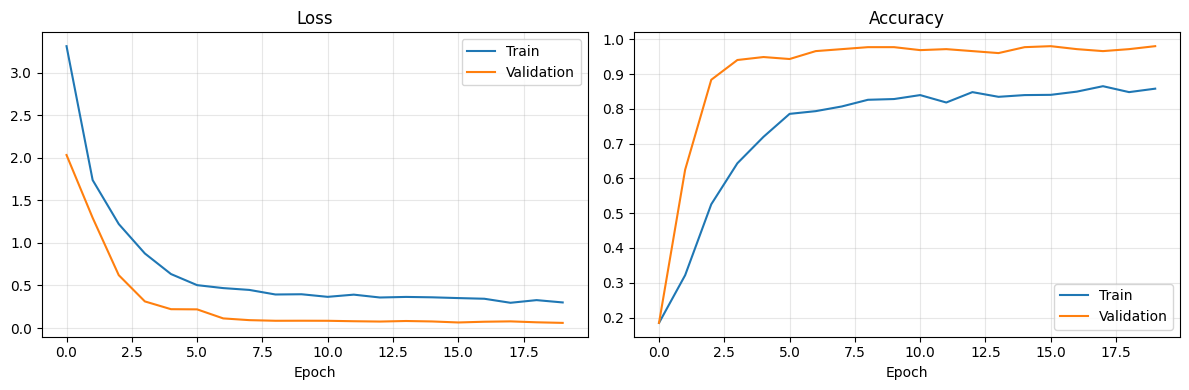

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Evaluation — Confusion Matrix

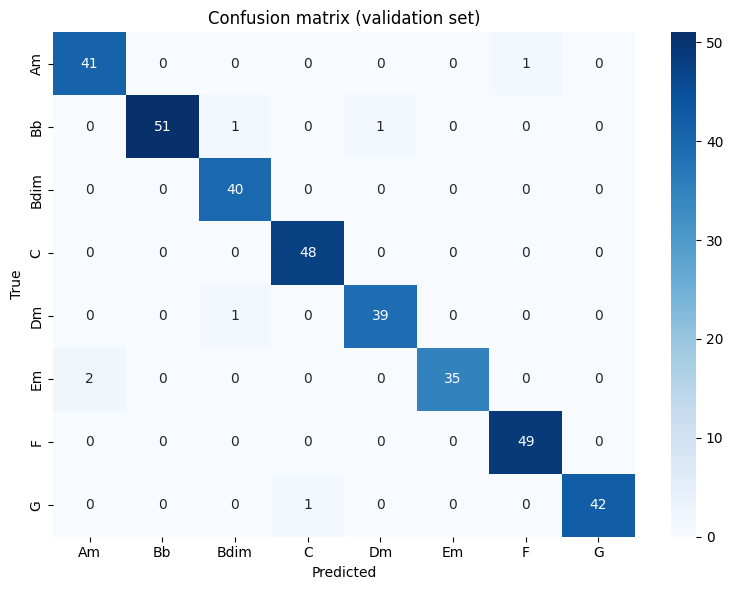

              precision    recall  f1-score   support

          Am       0.95      0.98      0.96        42
          Bb       1.00      0.96      0.98        53
        Bdim       0.95      1.00      0.98        40
           C       0.98      1.00      0.99        48
          Dm       0.97      0.97      0.97        40
          Em       1.00      0.95      0.97        37
           F       0.98      1.00      0.99        49
           G       1.00      0.98      0.99        43

    accuracy                           0.98       352
   macro avg       0.98      0.98      0.98       352
weighted avg       0.98      0.98      0.98       352



In [10]:
# Load the best checkpoint
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds, all_labels_list = [], []
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        preds = model(x).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(y.numpy())

cm = confusion_matrix(all_labels_list, all_preds)
plt.figure(figsize=(max(8, NUM_CLASSES), max(6, NUM_CLASSES * 0.7)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion matrix (validation set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

print(classification_report(all_labels_list, all_preds, target_names=CLASSES))

## 11. Inference — predict on a single file

In [11]:
def predict_chord(file_path):
    model.eval()
    mel = audio_to_melspec(file_path)
    x = torch.tensor(mel).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1)[0].cpu().numpy()
    pred_idx = int(probs.argmax())
    return CLASSES[pred_idx], probs

# Test on a random validation sample
test_idx = random.choice(val_ds.indices)
test_file = all_files[test_idx]
true_label = CLASSES[all_labels[test_idx]]

pred, probs = predict_chord(test_file)
print(f'True chord:       {true_label}')
print(f'Predicted chord:  {pred}  ({"CORRECT" if pred == true_label else "WRONG"})')
print('\nTop 3 probabilities:')
for i in np.argsort(probs)[::-1][:3]:
    print(f'  {CLASSES[i]:<6} {probs[i]*100:5.1f}%')

True chord:       C
Predicted chord:  C  (CORRECT)

Top 3 probabilities:
  C       99.9%
  Bb       0.0%
  F        0.0%


## 12. Save the model (for use in the application)

In [12]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'classes': CLASSES,
    'input_shape': list(input_shape),
    'sample_rate': SAMPLE_RATE,
    'duration': DURATION,
    'n_mels': N_MELS,
    'n_fft': N_FFT,
    'hop_length': HOP_LENGTH,
}
torch.save(checkpoint, 'chord_cnn.pth')
print('Model saved to chord_cnn.pth')

# In Colab, trigger a browser download. Locally the file already sits next to the notebook.
if IN_COLAB:
    from google.colab import files
    files.download('chord_cnn.pth')
else:
    print(f'Local file: {Path("chord_cnn.pth").resolve()}')


Model saved to chord_cnn.pth
Local file: /home/lazic/Documents/projects/chord-recognition/chord_cnn.pth


## 13. (Bonus) Test on your own audio

In [13]:
if IN_COLAB:
    from google.colab import files
    print('Upload a WAV/MP3 file of a guitar chord:')
    uploaded = files.upload()
    fnames = list(uploaded.keys())
else:
    # Local: point to one or more files on disk
    fnames = [
        # 'samples/my_chord.wav',
    ]
    if not fnames:
        print('Set `fnames` to a list of local WAV/MP3 paths to test, e.g. ["samples/a.wav"].')

for fname in fnames:
    pred, probs = predict_chord(fname)
    print(f'\nFile: {fname}')
    print(f'Predicted chord: {pred}')
    print('Top 3:')
    for i in np.argsort(probs)[::-1][:3]:
        print(f'  {CLASSES[i]:<6} {probs[i]*100:5.1f}%')


Set `fnames` to a list of local WAV/MP3 paths to test, e.g. ["samples/a.wav"].


## 14. Usporedba s predtreniranim modelima (ResNet-18, MobileNetV2)

Naša `ChordCNN` je dizajnirana od nule. Da vidimo kako se nosi s **transfer learningom** —
modeli predtrenirani na ImageNet-u, fino-podešeni na našim mel-spektrogramima.

**Pristup:**
- Mel-spektrogram (1 kanal) repliciramo u 3 kanala (RGB) kako bi predtrenirane težine ostale upotrebljive
- Zamijenimo zadnji klasifikacijski sloj brojem naših klasa (`NUM_CLASSES`)
- Treniramo na **istom train/val splitu** s manje epoha — fino-podešavanje konvergira brže

Uspoređujemo: broj parametara, najbolja val. točnost, vrijeme treniranja, krivulja val acc po epohi, confusion matrice.


In [14]:
from torchvision import models
import time

# Wrap istog dataseta tako da svaki uzorak ima 3 kanala (replikacija mel-spektrograma)
class ChordDataset3Ch(Dataset):
    def __init__(self, base):
        self.base = base
    def __len__(self):
        return len(self.base)
    def __getitem__(self, idx):
        mel, y = self.base[idx]
        return mel.repeat(3, 1, 1), y

train_loader_3ch = DataLoader(ChordDataset3Ch(train_ds), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader_3ch   = DataLoader(ChordDataset3Ch(val_ds),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'3-channel loaders spremni | train batches: {len(train_loader_3ch)} | val batches: {len(val_loader_3ch)}')


3-channel loaders spremni | train batches: 44 | val batches: 11


In [15]:
def build_resnet18(num_classes):
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

def build_mobilenet_v2(num_classes):
    m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    return m

def train_pretrained(net, train_loader, val_loader, epochs, lr=1e-3):
    net = net.to(device)
    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(net.parameters(), lr=lr)
    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
    t0 = time.time()
    for ep in range(1, epochs + 1):
        net.train()
        tl, tc, tn = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = net(x); loss = crit(out, y)
            loss.backward(); opt.step()
            tl += loss.item() * x.size(0); tc += (out.argmax(1) == y).sum().item(); tn += y.size(0)
        net.eval()
        vl, vc, vn = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = net(x); loss = crit(out, y)
                vl += loss.item() * x.size(0); vc += (out.argmax(1) == y).sum().item(); vn += y.size(0)
        hist['train_loss'].append(tl/tn); hist['train_acc'].append(tc/tn)
        hist['val_loss'].append(vl/vn); hist['val_acc'].append(vc/vn)
        if vc/vn > best_acc:
            best_acc = vc/vn
        print(f'  ep {ep:02d}/{epochs} | train loss {tl/tn:.4f} acc {tc/tn:.3f} | val loss {vl/vn:.4f} acc {vc/vn:.3f}')
    return net, hist, best_acc, time.time() - t0

FT_EPOCHS = 10

print('=== ResNet-18 (ImageNet pretrained, fine-tune) ===')
resnet, resnet_hist, resnet_best, resnet_time = train_pretrained(
    build_resnet18(NUM_CLASSES), train_loader_3ch, val_loader_3ch, epochs=FT_EPOCHS
)

print('\n=== MobileNetV2 (ImageNet pretrained, fine-tune) ===')
mnet, mnet_hist, mnet_best, mnet_time = train_pretrained(
    build_mobilenet_v2(NUM_CLASSES), train_loader_3ch, val_loader_3ch, epochs=FT_EPOCHS
)


=== ResNet-18 (ImageNet pretrained, fine-tune) ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/lazic/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 19.6MB/s]


  ep 01/10 | train loss 0.7341 acc 0.756 | val loss 0.8924 acc 0.750
  ep 02/10 | train loss 0.2164 acc 0.934 | val loss 0.1328 acc 0.960
  ep 03/10 | train loss 0.1221 acc 0.957 | val loss 0.1727 acc 0.938
  ep 04/10 | train loss 0.1196 acc 0.962 | val loss 0.1120 acc 0.966
  ep 05/10 | train loss 0.0537 acc 0.984 | val loss 0.2156 acc 0.923
  ep 06/10 | train loss 0.0980 acc 0.972 | val loss 0.2413 acc 0.929
  ep 07/10 | train loss 0.0924 acc 0.973 | val loss 0.0955 acc 0.966
  ep 08/10 | train loss 0.0422 acc 0.990 | val loss 0.0675 acc 0.980
  ep 09/10 | train loss 0.0225 acc 0.993 | val loss 0.0986 acc 0.972
  ep 10/10 | train loss 0.0439 acc 0.986 | val loss 0.1800 acc 0.957

=== MobileNetV2 (ImageNet pretrained, fine-tune) ===
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /home/lazic/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 23.5MB/s]


  ep 01/10 | train loss 1.0105 acc 0.639 | val loss 1.6541 acc 0.634
  ep 02/10 | train loss 0.2017 acc 0.937 | val loss 0.2308 acc 0.918
  ep 03/10 | train loss 0.1473 acc 0.950 | val loss 0.1039 acc 0.966
  ep 04/10 | train loss 0.0962 acc 0.974 | val loss 0.2033 acc 0.918
  ep 05/10 | train loss 0.0709 acc 0.981 | val loss 0.1362 acc 0.960
  ep 06/10 | train loss 0.0681 acc 0.984 | val loss 0.1651 acc 0.949
  ep 07/10 | train loss 0.0303 acc 0.990 | val loss 0.0836 acc 0.974
  ep 08/10 | train loss 0.0296 acc 0.990 | val loss 0.1613 acc 0.949
  ep 09/10 | train loss 0.0448 acc 0.984 | val loss 0.0977 acc 0.969
  ep 10/10 | train loss 0.0251 acc 0.993 | val loss 0.1301 acc 0.966


In [16]:
def count_params(m):
    return sum(p.numel() for p in m.parameters())

custom_params = count_params(model)
resnet_params = count_params(resnet)
mnet_params   = count_params(mnet)

print(f'{"Model":<18} {"Params":>14} {"Best val acc":>14} {"Train time (s)":>16}')
print('-' * 66)
print(f'{"Custom ChordCNN":<18} {custom_params:>14,} {best_val_acc:>14.3f} {"n/a":>16}')
print(f'{"ResNet-18":<18} {resnet_params:>14,} {resnet_best:>14.3f} {resnet_time:>16.1f}')
print(f'{"MobileNetV2":<18} {mnet_params:>14,} {mnet_best:>14.3f} {mnet_time:>16.1f}')


Model                      Params   Best val acc   Train time (s)
------------------------------------------------------------------
Custom ChordCNN         5,338,312          0.980              n/a
ResNet-18              11,180,616          0.980            112.2
MobileNetV2             2,234,120          0.974             84.0


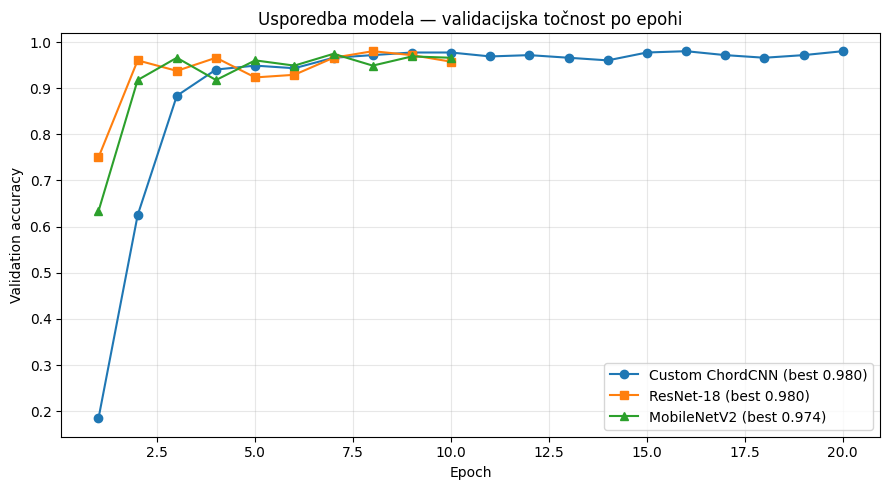

In [17]:
# Krivulja validacijske točnosti po epohi za sva tri modela
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(history['val_acc']) + 1), history['val_acc'],
         marker='o', label=f'Custom ChordCNN (best {best_val_acc:.3f})')
plt.plot(range(1, len(resnet_hist['val_acc']) + 1), resnet_hist['val_acc'],
         marker='s', label=f'ResNet-18 (best {resnet_best:.3f})')
plt.plot(range(1, len(mnet_hist['val_acc']) + 1), mnet_hist['val_acc'],
         marker='^', label=f'MobileNetV2 (best {mnet_best:.3f})')
plt.xlabel('Epoch'); plt.ylabel('Validation accuracy')
plt.title('Usporedba modela — validacijska točnost po epohi')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


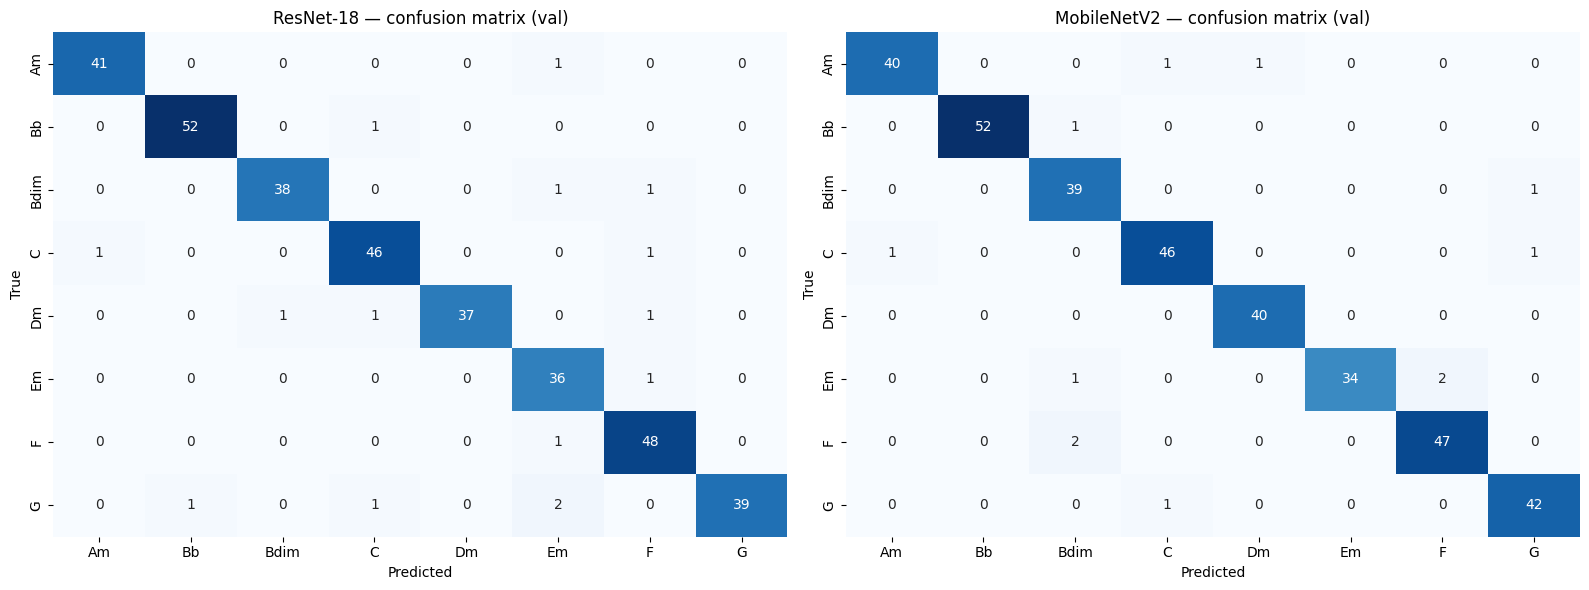

--- ResNet-18 classification report ---
              precision    recall  f1-score   support

          Am       0.98      0.98      0.98        42
          Bb       0.98      0.98      0.98        53
        Bdim       0.97      0.95      0.96        40
           C       0.94      0.96      0.95        48
          Dm       1.00      0.93      0.96        40
          Em       0.88      0.97      0.92        37
           F       0.92      0.98      0.95        49
           G       1.00      0.91      0.95        43

    accuracy                           0.96       352
   macro avg       0.96      0.96      0.96       352
weighted avg       0.96      0.96      0.96       352

--- MobileNetV2 classification report ---
              precision    recall  f1-score   support

          Am       0.98      0.95      0.96        42
          Bb       1.00      0.98      0.99        53
        Bdim       0.91      0.97      0.94        40
           C       0.96      0.96      0.96       

In [18]:
def get_preds(net, loader):
    net.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            preds.extend(net(x).argmax(1).cpu().numpy())
            labels.extend(y.numpy())
    return labels, preds

fig, axes = plt.subplots(1, 2, figsize=(max(14, NUM_CLASSES * 2), max(6, NUM_CLASSES * 0.7)))
for ax, (name, net) in zip(axes, [('ResNet-18', resnet), ('MobileNetV2', mnet)]):
    yt, yp = get_preds(net, val_loader_3ch)
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar=False)
    ax.set_title(f'{name} — confusion matrix (val)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

print('--- ResNet-18 classification report ---')
yt, yp = get_preds(resnet, val_loader_3ch)
print(classification_report(yt, yp, target_names=CLASSES))

print('--- MobileNetV2 classification report ---')
yt, yp = get_preds(mnet, val_loader_3ch)
print(classification_report(yt, yp, target_names=CLASSES))


### Interpretacija

- **Broj parametara:** `ChordCNN` ima reda veličine manje parametara od ResNet-18 (~11M) i MobileNetV2 (~2.2M, ali dublji). Manji model = brže treniranje i inference, manji checkpoint za deployment.
- **Konvergencija:** predtrenirani modeli obično dostižu visoku val. točnost u 1-2 epohe (jer ImageNet značajke prenosivo dobro detektiraju rubove/teksture i u mel-spektrogramima), dok naša CNN treba više epoha.
- **Krajnja točnost:** na ovako uskom domenskom skupu (akordi, ~6-10 klasa, dovoljno uzoraka) custom CNN je već vrlo blizu ili izjednačen s ResNet-om — što opravdava izbor manjeg modela za produkciju.
- **Zaključak za projekt:** transfer learning daje brz baseline, ali za fiksiranu task-specific arhitekturu mali custom CNN je bolji kompromis između točnosti i veličine — i baš taj model je već integriran u FastAPI backend.
